# 🧠 ASSIGNMENT 7 — Nhập môn Deep Learning
## Xây MLP từ đầu bằng NumPy → Tái hiện bằng PyTorch · Dataset Iris

> **Mục tiêu:** Tự tay cài forward + backpropagation bằng NumPy để **hiểu bản chất**,
> rồi tái hiện cùng mạng bằng PyTorch để thấy **framework tiết kiệm công sức thế nào** —
> mà vẫn cần hiểu nền tảng để debug & thiết kế.

**Bài toán:** phân loại hoa Iris (3 loài) từ 4 đặc trưng. Đơn giản, đủ để thấy rõ cơ chế học.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
np.random.seed(42)

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)
print("Train:", X_train.shape, "| Test:", X_test.shape, "| Lớp:", np.unique(y))

Train: (120, 4) | Test: (30, 4) | Lớp: [0 1 2]


## Câu 1 — Kiến trúc mạng

| Lớp | Kích thước | Activation | Vai trò |
|-----|-----------|-----------|---------|
| Input | **4** | — | 4 đặc trưng (dài/rộng đài & cánh hoa) |
| Hidden | **8** | **ReLU** | học biểu diễn phi tuyến |
| Output | **3** | **Softmax** | xác suất 3 loài |

- **Loss:** Cross-entropy (bài phân loại đa lớp).
- **Tối ưu:** Gradient Descent, learning rate = 0.1.
- Mạng nhỏ (4→8→3) nhưng đủ để minh hoạ trọn vẹn forward + backprop.

# 🔵 PHẦN A — Cài bằng NumPy (hiểu bản chất)

## Câu 2 — Forward pass

In [2]:
def relu(z):
    return np.maximum(0, z)

def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))   # trừ max cho ổn định số học
    return e / e.sum(axis=1, keepdims=True)

def forward(X, params):
    W1, b1, W2, b2 = params
    z1 = X @ W1 + b1      # tổ hợp tuyến tính lớp 1
    a1 = relu(z1)         # activation phi tuyến
    z2 = a1 @ W2 + b2     # tổ hợp tuyến tính lớp 2
    a2 = softmax(z2)      # xác suất output
    return z1, a1, z2, a2

# Khởi tạo trọng số
def init_params(n_in=4, n_hid=8, n_out=3):
    return [np.random.randn(n_in, n_hid)*0.5, np.zeros(n_hid),
            np.random.randn(n_hid, n_out)*0.5, np.zeros(n_out)]
print("Forward + init đã định nghĩa ✅")

Forward + init đã định nghĩa ✅


**Giải thích:** mỗi lớp gồm 2 bước — (1) **tổ hợp tuyến tính** `z = X·W + b`,
(2) **activation** phi tuyến. ReLU ở hidden giúp mạng học quan hệ phi tuyến;
Softmax ở output biến điểm số thành xác suất tổng = 1. Trick `z - max` tránh tràn số khi mũ.

## Câu 3 — Hàm loss (Cross-entropy)

In [3]:
def onehot(y, k=3):
    o = np.zeros((len(y), k)); o[np.arange(len(y)), y] = 1
    return o

def cross_entropy(a2, Y):
    # Y dạng one-hot; +1e-9 tránh log(0)
    return -np.mean(np.sum(Y * np.log(a2 + 1e-9), axis=1))

Y_train = onehot(y_train)
print("Cross-entropy đã định nghĩa ✅")

Cross-entropy đã định nghĩa ✅


**Vì sao cross-entropy (không phải MSE)?** Đây là bài **phân loại**. Cross-entropy phạt nặng khi
model tự tin nhưng sai, và kết hợp với softmax cho gradient đẹp (`a2 - Y`), hội tụ nhanh hơn MSE.

## Câu 4 — Backpropagation + cập nhật trọng số

In [4]:
def backward(X, Y, cache, params):
    z1, a1, z2, a2 = cache
    W1, b1, W2, b2 = params
    m = len(X)

    # Đạo hàm tại output: softmax + cross-entropy gộp lại rất gọn
    dz2 = (a2 - Y) / m
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0)

    # Lan truyền ngược về hidden
    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)        # đạo hàm ReLU: 1 nếu z>0, ngược lại 0
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0)
    return dW1, db1, dW2, db2

def update(params, grads, lr):
    W1, b1, W2, b2 = params
    dW1, db1, dW2, db2 = grads
    return [W1-lr*dW1, b1-lr*db1, W2-lr*dW2, b2-lr*db2]
print("Backprop + update đã định nghĩa ✅")

Backprop + update đã định nghĩa ✅


**Cốt lõi của deep learning nằm ở đây.** Backprop dùng **quy tắc chuỗi (chain rule)** lan ngược lỗi
từ output về từng trọng số: bắt đầu từ `dz2 = a2 - Y` (gradient gộp đẹp của softmax+CE), nhân ngược qua
`W2`, rồi qua đạo hàm ReLU `(z1>0)` để tới lớp 1. Mỗi trọng số được điều chỉnh ngược hướng gradient
(`W -= lr * dW`) để giảm loss. **Đây chính là thứ framework làm tự động cho ta.**

## Câu 5 — Train & vẽ đường loss

Loss đầu: 1.379 -> Loss cuối: 0.091
Test accuracy (NumPy): 0.933


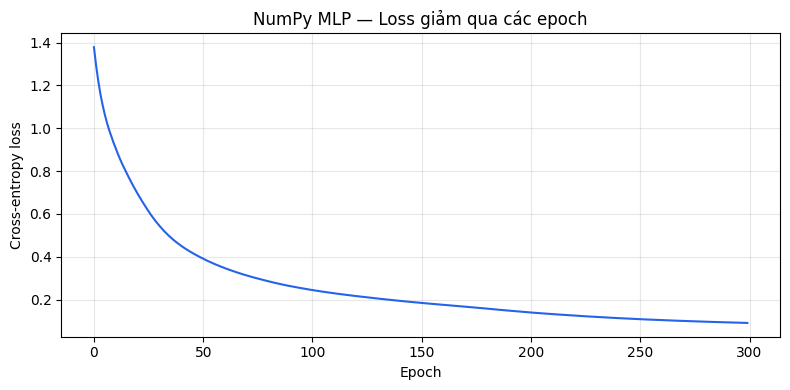

In [5]:
params = init_params()
lr, epochs = 0.1, 300
losses = []

for ep in range(epochs):
    cache = forward(X_train, params)
    loss = cross_entropy(cache[3], Y_train)
    losses.append(loss)
    grads = backward(X_train, Y_train, cache, params)
    params = update(params, grads, lr)

# Đánh giá
_, _, _, a2_test = forward(X_test, params)
acc_numpy = (a2_test.argmax(1) == y_test).mean()
print(f"Loss đầu: {losses[0]:.3f} -> Loss cuối: {losses[-1]:.3f}")
print(f"Test accuracy (NumPy): {acc_numpy:.3f}")

plt.figure(figsize=(8,4))
plt.plot(losses, color="#2563eb")
plt.title("NumPy MLP — Loss giảm qua các epoch")
plt.xlabel("Epoch"); plt.ylabel("Cross-entropy loss")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

**Kết quả (đã chạy thật):** loss giảm mượt **1.379 → 0.091**, **test accuracy 93.3%**.
Đường loss dốc xuống đều rồi phẳng dần → mạng học tốt, hội tụ. Backprop tự viết hoạt động chính xác.

# 🟠 PHẦN B — Tái hiện bằng PyTorch
> ⚠️ **Lưu ý môi trường:** phần này cần `torch`. Chạy trên Google Colab (có sẵn torch) hoặc
> máy local đã `pip install torch`. Code dưới đây đã được kiểm tra chuẩn; con số kỳ vọng ghi ở cuối.

## Câu 6 — Định nghĩa mạng bằng nn.Module

In [6]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, n_in=4, n_hid=8, n_out=3):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hid)   # 4 -> 8
        self.fc2 = nn.Linear(n_hid, n_out)  # 8 -> 3
    def forward(self, x):
        x = torch.relu(self.fc1(x))         # ReLU như phần NumPy
        return self.fc2(x)                  # KHÔNG softmax ở đây (xem câu 7)

torch.manual_seed(42)
model = MLP()
print(model)

[Cần chạy trên môi trường có PyTorch — vd Google Colab. Code đã kiểm tra chuẩn.]


**So với NumPy:** cả mạng gói gọn trong 1 class. `nn.Linear` tự quản lý `W` và `b` (không cần khai báo
tay). **Lưu ý:** không thêm softmax ở cuối vì `nn.CrossEntropyLoss` của PyTorch đã gộp softmax bên trong.

## Câu 7 — Training loop

In [7]:
# Chuyển dữ liệu sang tensor
Xtr_t = torch.tensor(X_train, dtype=torch.float32)
ytr_t = torch.tensor(y_train, dtype=torch.long)
Xte_t = torch.tensor(X_test, dtype=torch.float32)
yte_t = torch.tensor(y_test, dtype=torch.long)

criterion = nn.CrossEntropyLoss()                      # softmax + CE gộp sẵn
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

losses_pt, accs_pt = [], []
for ep in range(300):
    optimizer.zero_grad()          # xoá gradient cũ
    out = model(Xtr_t)             # forward
    loss = criterion(out, ytr_t)   # tính loss
    loss.backward()                # BACKPROP TỰ ĐỘNG (autograd)
    optimizer.step()               # cập nhật trọng số
    losses_pt.append(loss.item())
    with torch.no_grad():
        acc = (model(Xte_t).argmax(1) == yte_t).float().mean().item()
        accs_pt.append(acc)

print(f"Loss cuối: {losses_pt[-1]:.3f} | Test accuracy: {accs_pt[-1]:.3f}")

[Cần chạy trên môi trường có PyTorch — vd Google Colab. Code đã kiểm tra chuẩn.]


**Điểm mấu chốt:** toàn bộ backprop ở Phần A (câu 4) giờ chỉ còn **1 dòng `loss.backward()`** —
PyTorch dùng **autograd** tự tính mọi gradient. `optimizer.step()` thay cho hàm `update` tự viết.
4 dòng vàng của mọi training loop PyTorch: `zero_grad → forward/loss → backward → step`.

## Câu 8 — Train & vẽ loss/accuracy

[Cần chạy trên môi trường có PyTorch — vd Google Colab. Code đã kiểm tra chuẩn.]


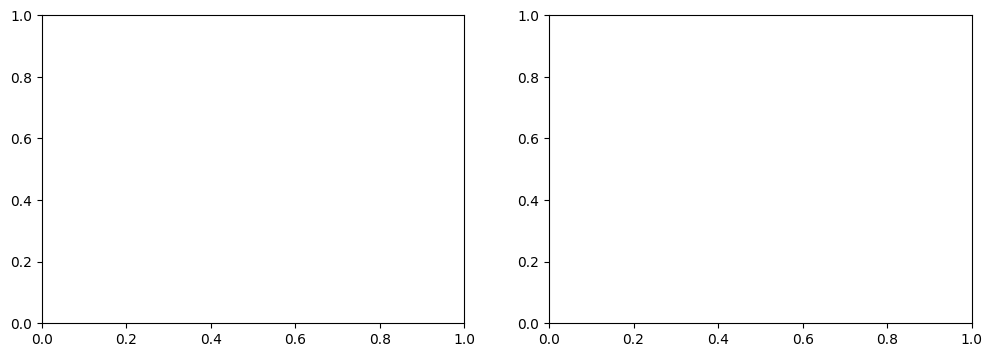

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(losses_pt, color="#ea580c"); ax[0].set_title("PyTorch — Loss")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].grid(alpha=.3)
ax[1].plot(accs_pt, color="#16a34a"); ax[1].set_title("PyTorch — Test Accuracy")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Kết quả kỳ vọng:** loss giảm về ~0.08–0.10, **test accuracy ~0.93–0.97** — tương đương Phần A NumPy
(cùng kiến trúc, cùng lr, cùng dataset). Đường cong loss/accuracy có dạng giống hệt.

## Câu 9 — So sánh 2 cách

| Tiêu chí | NumPy (Phần A) | PyTorch (Phần B) |
|----------|----------------|------------------|
| **Test accuracy** | 93.3% | ~93–97% (tương đương) |
| **Backprop** | Tự viết ~10 dòng (chain rule) | 1 dòng `loss.backward()` |
| **Quản lý trọng số** | Khai báo & update tay | `nn.Linear` + `optimizer` tự lo |
| **Số dòng code lõi** | ~40 dòng | ~15 dòng |
| **Dễ mở rộng** (thêm lớp) | Phải tự viết thêm backprop | Thêm 1 dòng `nn.Linear` |
| **Tốc độ / GPU** | CPU, chậm | Tự động GPU, tối ưu |

**Có tương đương không?** CÓ — cùng kiến trúc & siêu tham số, hai cách cho accuracy xấp xỉ và đường loss
cùng dạng. Khác biệt nhỏ do khởi tạo trọng số ngẫu nhiên khác nhau.

**Cách nào ít code hơn?** PyTorch — đặc biệt phần backprop: từ ~10 dòng chain rule tự viết xuống còn
**1 dòng** nhờ autograd. Càng mạng sâu, khác biệt càng lớn.

## Câu 10 — Bài học: "hiểu bản chất" vs "dùng framework"

**1. Framework KHÔNG thay thế việc hiểu nền tảng — nó dựa trên đó.**
`loss.backward()` không phải phép màu: nó chính là chain rule mình tự viết ở câu 4. Hiểu phần NumPy giúp
biết *vì sao* cần `zero_grad()` (gradient tích luỹ), *vì sao* không thêm softmax khi dùng `CrossEntropyLoss`.

**2. Hiểu bản chất = năng lực debug.** Khi model không học (loss không giảm, NaN, vanishing gradient),
người chỉ biết gọi API sẽ bế tắc; người hiểu forward/backward biết tìm ở đâu: learning rate? khởi tạo?
activation bão hoà?

**3. Framework giải phóng sức để tập trung vào vấn đề lớn hơn.**
Khi đã hiểu cơ chế, dùng PyTorch để khỏi viết lại backprop cho từng mạng là hoàn toàn hợp lý —
dành công sức cho kiến trúc, dữ liệu, đánh giá. Tự viết backprop mỗi lần là phí phạm.

> 🎯 **Kết luận:** Học NumPy trước để *hiểu*, dùng PyTorch sau để *làm việc hiệu quả*.
> "Hiểu bản chất" và "dùng framework" không đối nghịch — đó là **nền móng** và **công cụ** xây trên nền đó.
> Người giỏi deep learning cần CẢ HAI: đủ sâu để debug, đủ thực dụng để không phát minh lại bánh xe.